# Cold Diffusion Models — Notebook 00: Setup & Data Preparation
This notebook validates the environment, installs any remaining dependencies, and downloads/prepares all datasets (MNIST, CIFAR-10) that are used by the Cold Diffusion experiments.\n

## Table of Contents
1. GPU & Environment Check
2. Dependency Verification
3. Global Configuration
4. MNIST Dataset Preparation
5. CIFAR-10 Dataset Preparation
6. CelebA & AFHQ Datasets (Manual Download)
7. Directory Structure Summary

## 1. GPU & Environment Check

In [1]:
import torch
import sys
import subprocess

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory: {mem_gb:.1f} GB")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("WARNING: No GPU found. Training will be very slow on CPU.")

try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,driver_version', 
                             '--format=csv,noheader'], capture_output=True, text=True, timeout=10)
    if result.returncode == 0:
        print(f"\nnvidia-smi output:\n{result.stdout.strip()}")
except Exception:
    pass

Python version: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
PyTorch version: 2.13.0a0+8145d630e8.nv26.06
CUDA available: True
GPU device: NVIDIA GeForce RTX 3090
GPU memory: 25.3 GB
CUDA version: 13.3
Number of GPUs: 1

nvidia-smi output:
NVIDIA GeForce RTX 3090, 24576 MiB, 595.71.05


## 2. Dependency Verification

In [2]:
packages = [
    ('torch',           'PyTorch'),
    ('torchvision',     'TorchVision'),
    ('einops',          'Einops'),
    ('numpy',           'NumPy'),
    ('PIL',             'Pillow'),
    ('tqdm',            'TQDM'),
    ('matplotlib',      'Matplotlib'),
    ('seaborn',         'Seaborn'),
    ('torchgeometry',   'TorchGeometry'),
    ('kornia',          'Kornia'),
    ('scipy',           'SciPy'),
    ('cv2',             'OpenCV'),
    ('imageio',         'ImageIO'),
    ('sklearn',         'Scikit-Learn'),
    ('pytorch_msssim',  'PyTorch-MSSSIM'),
    ('pytorch_fid',     'PyTorch-FID'),
    ('comet_ml',        'CometML'),
    ('skimage',         'Scikit-Image'),
]

all_ok = True
for module, name in packages:
    try:
        mod = __import__(module)
        ver = getattr(mod, '__version__', 'n/a')
        print(f"  ✓ {name:<20} {ver}")
    except ImportError:
        print(f"  ✗ {name:<20} MISSING — run: pip install {module}")
        all_ok = False

print()
if all_ok:
    print("All dependencies are installed!")
else:
    print("WARNING: Some dependencies are missing. Install them before running experiments.")

  ✓ PyTorch              2.13.0a0+8145d630e8.nv26.06
  ✓ TorchVision          0.27.0a0+499ca510.nv26.06
  ✓ Einops               0.8.2
  ✓ NumPy                2.1.0
  ✓ Pillow               12.2.0
  ✓ TQDM                 4.68.2
  ✓ Matplotlib           3.10.9
  ✓ Seaborn              0.13.2
  ✓ TorchGeometry        0.1.2
  ✓ Kornia               0.8.3
  ✓ SciPy                1.17.1
  ✓ OpenCV               4.13.0
  ✓ ImageIO              2.37.3
  ✓ Scikit-Learn         1.9.0
  ✓ PyTorch-MSSSIM       n/a
  ✓ PyTorch-FID          0.3.0
  ✓ CometML              3.58.3
  ✓ Scikit-Image         0.26.0

All dependencies are installed!


## 3. Global Configuration

In [3]:
import os
import random
from pathlib import Path
import numpy as np

REPO_ROOT       = Path('/workspace')
DATA_ROOT       = REPO_ROOT / 'data'
CHECKPOINTS    = REPO_ROOT / 'checkpoints'
RESULTS        = REPO_ROOT / 'results'

MNIST_TRAIN     = DATA_ROOT / 'root_mnist'
MNIST_TEST      = DATA_ROOT / 'root_mnist_test'
CIFAR10_TRAIN   = DATA_ROOT / 'root_cifar10'
CIFAR10_TEST    = DATA_ROOT / 'root_cifar10_test'

CELEBA_TRAIN    = DATA_ROOT / 'root_celebA_128_train'
CELEBA_TEST     = DATA_ROOT / 'root_celebA_128_test'
AFHQ_TRAIN      = DATA_ROOT / 'afhq' / 'train'
AFHQ_VAL        = DATA_ROOT / 'afhq' / 'val'

for d in [
    DATA_ROOT, CHECKPOINTS, RESULTS,
    CHECKPOINTS / 'blur',        RESULTS / 'blur',
    CHECKPOINTS / 'inpainting',  RESULTS / 'inpainting',
    CHECKPOINTS / 'super_resolution', RESULTS / 'super_resolution',
    CHECKPOINTS / 'snow',        RESULTS / 'snow',
    CHECKPOINTS / 'colorization',RESULTS / 'colorization',
    CHECKPOINTS / 'animorphosis',RESULTS / 'animorphosis',
    CHECKPOINTS / 'denoising',   RESULTS / 'denoising',
    RESULTS / 'blur_unconditional',
    RESULTS / 'inpainting_unconditional',
    RESULTS / 'figures',
]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
import torch
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Random seed: {RANDOM_SEED}')
print(f'\nKey paths:')
print(f'  REPO_ROOT:    {REPO_ROOT}')
print(f'  DATA_ROOT:    {DATA_ROOT}')
print(f'  CHECKPOINTS:  {CHECKPOINTS}')
print(f'  RESULTS:      {RESULTS}')

Device: cuda
Random seed: 42

Key paths:
  REPO_ROOT:    /workspace
  DATA_ROOT:    /workspace/data
  CHECKPOINTS:  /workspace/checkpoints
  RESULTS:      /workspace/results


## 4. MNIST Dataset Preparation

In [4]:
import torchvision
import shutil
import errno
from PIL import Image as PILImage

def create_folder(path):
    try:
        os.mkdir(str(path))
    except OSError as exc:
        if exc.errno != errno.EEXIST:
            raise

def del_folder(path):
    try:
        shutil.rmtree(str(path))
    except OSError:
        pass

if MNIST_TRAIN.exists() and any(MNIST_TRAIN.iterdir()):
    total = sum(len(list((MNIST_TRAIN/str(i)).glob('*.png'))) for i in range(10))
    print(f'MNIST train already prepared ({total:,} images) at {MNIST_TRAIN}')
else:
    print('Preparing MNIST training set...')
    raw_dir = DATA_ROOT / 'raw'
    trainset = torchvision.datasets.MNIST(root=str(raw_dir), train=True, download=True)
    del_folder(MNIST_TRAIN)
    create_folder(MNIST_TRAIN)
    for i in range(10):
        create_folder(MNIST_TRAIN / str(i))
    for idx in range(len(trainset)):
        img, label = trainset[idx]
        img.save(str(MNIST_TRAIN / str(label) / f'{idx}.png'))
    print(f'Done: {len(trainset):,} MNIST train images saved to {MNIST_TRAIN}')

if MNIST_TEST.exists() and any(MNIST_TEST.iterdir()):
    total = sum(len(list((MNIST_TEST/str(i)).glob('*.png'))) for i in range(10))
    print(f'MNIST test already prepared ({total:,} images) at {MNIST_TEST}')
else:
    print('Preparing MNIST test set...')
    raw_dir = DATA_ROOT / 'raw'
    testset = torchvision.datasets.MNIST(root=str(raw_dir), train=False, download=True)
    del_folder(MNIST_TEST)
    create_folder(MNIST_TEST)
    for i in range(10):
        create_folder(MNIST_TEST / str(i))
    for idx in range(len(testset)):
        img, label = testset[idx]
        img.save(str(MNIST_TEST / str(label) / f'{idx}.png'))
    print(f'Done: {len(testset):,} MNIST test images saved to {MNIST_TEST}')

Preparing MNIST training set...


100%|██████████| 9.91M/9.91M [00:03<00:00, 3.24MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 141kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 811kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.33MB/s]


Done: 60,000 MNIST train images saved to /workspace/data/root_mnist
Preparing MNIST test set...
Done: 10,000 MNIST test images saved to /workspace/data/root_mnist_test


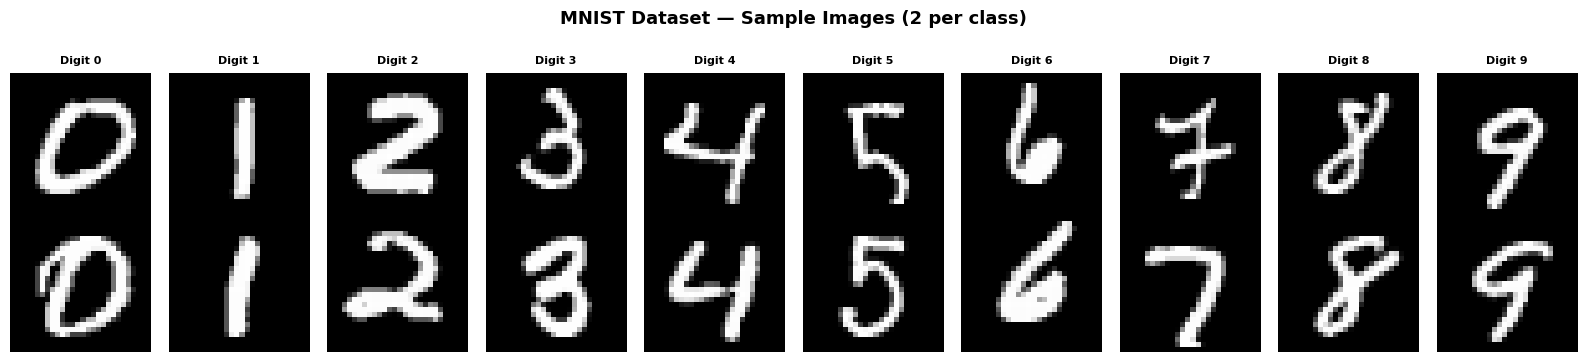

In [5]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
fig.suptitle('MNIST Dataset — Sample Images (2 per class)', fontsize=13, fontweight='bold', y=1.02)

for cls in range(10):
    imgs = list((MNIST_TRAIN / str(cls)).glob('*.png'))
    for row in range(2):
        if not imgs: continue
        sample = random.choice(imgs)
        img = PILImage.open(sample)
        axes[row, cls].imshow(img, cmap='gray', vmin=0, vmax=255)
        if row == 0:
            axes[row, cls].set_title(f'Digit {cls}', fontsize=8, fontweight='bold')
        axes[row, cls].axis('off')

plt.tight_layout()
save_path = RESULTS / 'mnist_samples.png'
plt.savefig(str(save_path), dpi=120, bbox_inches='tight')
plt.show()


## 5. CIFAR-10 Dataset Preparation

In [7]:
CIFAR10_CLASS_NAMES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

if CIFAR10_TRAIN.exists() and any(CIFAR10_TRAIN.iterdir()):
    total = sum(len(list((CIFAR10_TRAIN/str(i)).glob('*.png'))) for i in range(10))
    print(f'CIFAR-10 train already prepared ({total:,} images) at {CIFAR10_TRAIN}')
else:
    print('Preparing CIFAR-10 training set...')
    raw_dir = DATA_ROOT / 'raw'
    trainset = torchvision.datasets.CIFAR10(root=str(raw_dir), train=True, download=True)
    del_folder(CIFAR10_TRAIN)
    create_folder(CIFAR10_TRAIN)
    for i in range(10):
        create_folder(CIFAR10_TRAIN / str(i))
    for idx in range(len(trainset)):
        img, label = trainset[idx]
        img.save(str(CIFAR10_TRAIN / str(label) / f'{idx}.png'))
    print(f'Done: {len(trainset):,} CIFAR-10 train images saved to {CIFAR10_TRAIN}')

if CIFAR10_TEST.exists() and any(CIFAR10_TEST.iterdir()):
    total = sum(len(list((CIFAR10_TEST/str(i)).glob('*.png'))) for i in range(10))
    print(f'CIFAR-10 test already prepared ({total:,} images) at {CIFAR10_TEST}')
else:
    print('Preparing CIFAR-10 test set...')
    raw_dir = DATA_ROOT / 'raw'
    testset = torchvision.datasets.CIFAR10(root=str(raw_dir), train=False, download=True)
    del_folder(CIFAR10_TEST)
    create_folder(CIFAR10_TEST)
    for i in range(10):
        create_folder(CIFAR10_TEST / str(i))
    for idx in range(len(testset)):
        img, label = testset[idx]
        img.save(str(CIFAR10_TEST / str(label) / f'{idx}.png'))
    print(f'Done: {len(testset):,} CIFAR-10 test images saved to {CIFAR10_TEST}')

Preparing CIFAR-10 training set...


100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s] 


Done: 50,000 CIFAR-10 train images saved to /workspace/data/root_cifar10
Preparing CIFAR-10 test set...
Done: 10,000 CIFAR-10 test images saved to /workspace/data/root_cifar10_test


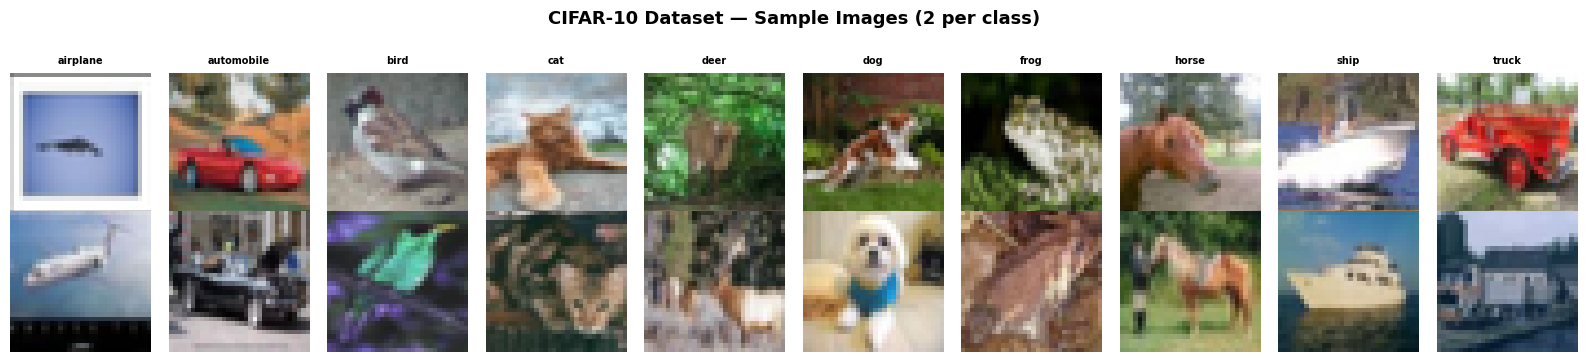

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
fig.suptitle('CIFAR-10 Dataset — Sample Images (2 per class)', fontsize=13, fontweight='bold', y=1.02)

for cls in range(10):
    imgs = list((CIFAR10_TRAIN / str(cls)).glob('*.png'))
    for row in range(2):
        if not imgs: continue
        sample = random.choice(imgs)
        img = PILImage.open(sample).convert('RGB')
        axes[row, cls].imshow(img)
        if row == 0:
            axes[row, cls].set_title(CIFAR10_CLASS_NAMES[cls], fontsize=7, fontweight='bold')
        axes[row, cls].axis('off')

plt.tight_layout()
save_path = RESULTS / 'cifar10_samples.png'
plt.savefig(str(save_path), dpi=120, bbox_inches='tight')
plt.show()

## 6. CelebA & AFHQ Datasets (Manual Download)

In [9]:
print('Large-scale Dataset Status')
print('=' * 60)

datasets = [
    ('CelebA-HQ 128x128 (train)', CELEBA_TRAIN),
    ('CelebA-HQ 128x128 (test)',  CELEBA_TEST),
    ('AFHQ 128x128 (train)',      AFHQ_TRAIN),
    ('AFHQ 128x128 (val)',        AFHQ_VAL),
]

for name, path in datasets:
    if path.exists():
        imgs = list(path.glob('**/*.png')) + list(path.glob('**/*.jpg'))
        print(f'  FOUND   {name}: {len(imgs):,} images at {path}')
    else:
        print(f'  MISSING {name}: expected at {path}')

print('\nDownload instructions:')
print('  CelebA-HQ 128x128:')
print('    https://drive.google.com/drive/folders/0B7EVK8r0v71pTUZsaXdaSnZBZzg')
print('  AFHQ:')
print('    https://github.com/clovaai/stargan-v2#datasets-and-pre-trained-networks')

Large-scale Dataset Status
  MISSING CelebA-HQ 128x128 (train): expected at /workspace/data/root_celebA_128_train
  MISSING CelebA-HQ 128x128 (test): expected at /workspace/data/root_celebA_128_test
  MISSING AFHQ 128x128 (train): expected at /workspace/data/afhq/train
  MISSING AFHQ 128x128 (val): expected at /workspace/data/afhq/val

Download instructions:
  CelebA-HQ 128x128:
    https://drive.google.com/drive/folders/0B7EVK8r0v71pTUZsaXdaSnZBZzg
  AFHQ:
    https://github.com/clovaai/stargan-v2#datasets-and-pre-trained-networks


## 7. Directory Structure Summary

In [10]:
def print_tree(path, prefix='', max_depth=3, current_depth=0):
    if current_depth > max_depth:
        return
    path = Path(path)
    if not path.exists():
        print(f'{prefix}{path.name}/ [NOT FOUND]')
        return
    items = sorted(path.iterdir())
    dirs  = [i for i in items if i.is_dir()]
    files = [i for i in items if i.is_file()]
    for d in dirs:
        n_children = len(list(d.rglob('*')))
        print(f'{prefix}├── {d.name}/ ({n_children} items)')
        if current_depth < max_depth - 1:
            print_tree(d, prefix + '│   ', max_depth, current_depth + 1)
    for f in files[:5]:
        print(f'{prefix}├── {f.name} ({f.stat().st_size:,} bytes)')
    if len(files) > 5:
        print(f'{prefix}└── ... and {len(files)-5} more files')

print(f'Repository structure:')
print(f'{REPO_ROOT}/')
for d in ['data', 'checkpoints', 'results', 'notebooks']:
    dpath = REPO_ROOT / d
    exists = dpath.exists()
    marker = '✓' if exists else '✗ (not found)'
    print(f'  {marker} {d}/')
    if exists and d in ['data', 'results', 'checkpoints']:
        subdirs = [x for x in dpath.iterdir() if x.is_dir()]
        for sd in sorted(subdirs)[:6]:
            n = len(list(sd.rglob('*')))
            print(f'       ├── {sd.name}/ ({n} items)')
print('\nSetup complete!')

Repository structure:
/workspace/
  ✓ data/
       ├── raw/ (20 items)
       ├── root_cifar10/ (50010 items)
       ├── root_cifar10_test/ (10010 items)
       ├── root_mnist/ (60010 items)
       ├── root_mnist_test/ (10010 items)
  ✓ checkpoints/
       ├── animorphosis/ (0 items)
       ├── blur/ (0 items)
       ├── colorization/ (0 items)
       ├── denoising/ (0 items)
       ├── inpainting/ (0 items)
       ├── snow/ (0 items)
  ✓ results/
       ├── animorphosis/ (0 items)
       ├── blur/ (0 items)
       ├── blur_unconditional/ (0 items)
       ├── colorization/ (0 items)
       ├── denoising/ (0 items)
       ├── figures/ (0 items)
  ✓ notebooks/

Setup complete!
